#  CRIMINALITÉ MONTRÉAL

## Projet D'analyse de la criminalité sur l'Île de Montréal de 2015 au 08 Avril 2026
aide de Claude.ia  -- *Source : Données ouvertes de la Ville de Montréal — mis à jour régulièrement*


### But de l'analyse

Existe-t-il une recrudescence de la criminalité à Montréal depuis quelques années ?

Arrivé à Montréal en octobre 2024, j'ai rapidement entendu des résidents affirmer que la criminalité ne cessait d'augmenter depuis des années. Plutôt que de me fier aux impressions, j'ai découvert que la Ville de Montréal mettait à disposition des données ouvertes mises à jour régulièrement, une opportunité idéale pour laisser les chiffres répondre à la question.

Ce projet est une démarche personnelle visant à développer mes compétences en analyse de données. J'ai utilisé Claude IA comme outil.

Dans ce notebook Python, l'analyse porte principalement sur la temporalité des faits : évolution annuelle, saisonnalité et répartition par catégorie de crime. Une seconde analyse (PostgreSQL + Power BI) approfondira les dimensions spatiales et permettra une visualisation orientée décision.

### Importation - Librairie

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap



### I. Chargement et exploration des données

In [3]:
# import du fichier 
gdf = gpd.read_file(r"C:\Users\domin\repos\dataset\crime_montreal\actes-criminels.shp")

# informations de base sur le dataset
print("=== DIMENSION ===")
print("Dimensions :", gdf.shape)
print("\n=== NOM DES COLONNES ===")
print("Colonnes :", gdf.columns.tolist())
print("\n=== PÉRIODE DES DONNÉES ===")
print(f"Plage de dates : {gdf['DATE'].min()} - {gdf['DATE'].max()}")
print("\n=== APERÇU ===")
gdf.head()

=== DIMENSION ===
Dimensions : (346296, 9)

=== NOM DES COLONNES ===
Colonnes : ['CATEGORIE', 'DATE', 'QUART', 'PDQ', 'X', 'Y', 'LONGITUDE', 'LATITUDE', 'geometry']

=== PÉRIODE DES DONNÉES ===
Plage de dates : 2015-01-01 - 2026-04-08

=== APERÇU ===


,CATEGORIE,DATE,QUART,PDQ,X,Y,LONGITUDE,LATITUDE,geometry
0,Vol de véhicule à moteur,2018-09-13,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780,POINT (-73.62678 45.56778)
1,Vol de véhicule à moteur,2018-04-30,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780,POINT (-73.62678 45.56778)
2,Vol de véhicule à moteur,2018-09-01,nuit,7.0,290274.565000,5.042150e+06,-73.685928,45.519122,POINT (-73.68593 45.51912)
3,Méfait,2017-07-21,jour,21.0,NaN,NaN,NaN,NaN,POINT (-76.23729 0)
4,Méfait,2017-07-29,jour,12.0,NaN,NaN,NaN,NaN,POINT (-76.23729 0)


In [4]:
print("=== DESCRIBES DES DONNÉES NUMÉRIQUES ===")
gdf.describe()

=== DESCRIBES DES DONNÉES NUMÉRIQUES ===


,PDQ,X,Y,LONGITUDE,LATITUDE
count,346290.000000,288231.000000,2.882310e+05,288231.000000,288231.000000
mean,26.022461,295782.430658,5.043091e+06,-73.615410,45.527648
std,13.953863,6101.609172,5.993644e+03,0.078024,0.053983
min,1.000000,268109.610010,5.029291e+06,-73.968954,45.402691
25%,15.000000,293912.474998,5.039046e+06,-73.639398,45.491095
50%,24.000000,297401.754009,5.042637e+06,-73.594677,45.523619
75%,38.000000,299674.890005,5.046813e+06,-73.565691,45.561178
max,55.000000,306389.863000,5.062496e+06,-73.479583,45.702351


In [5]:

# Quelles catégories de crimes ?
print("=== CATÉGORIES ===")
print(gdf['CATEGORIE'].value_counts())

print("\n=== PÉRIODE COUVERTE ===")
print(gdf['DATE'].min(), "→", gdf['DATE'].max())

print("\n=== QUART (moment de la journée) ===")
print(gdf['QUART'].value_counts())

print("\n=== DONNÉES MANQUANTES ===")
print(gdf.isnull().sum())

=== CATÉGORIES ===
CATEGORIE
Vol dans / sur véhicule à moteur    98407
Introduction                        81768
Méfait                              75040
Vol de véhicule à moteur            70488
Vols qualifiés                      20270
Infractions entrainant la mort        323
Name: count, dtype: int64

=== PÉRIODE COUVERTE ===
2015-01-01 → 2026-04-08

=== QUART (moment de la journée) ===
QUART
jour    176830
soir    113824
nuit     55642
Name: count, dtype: int64

=== DONNÉES MANQUANTES ===
CATEGORIE        0
DATE             0
QUART            0
PDQ              6
X            58065
Y            58065
LONGITUDE    58065
LATITUDE     58065
geometry         0
dtype: int64


### II. visualisation graphique de l'analyse 

#### 1. Visualisation des fait et de la temporalité.

Convertir la colonne `DATE` en datetime et produire deux graphiques d'ensemble :
la répartition des crimes par catégorie et l'évolution annuelle sur 11 ans.

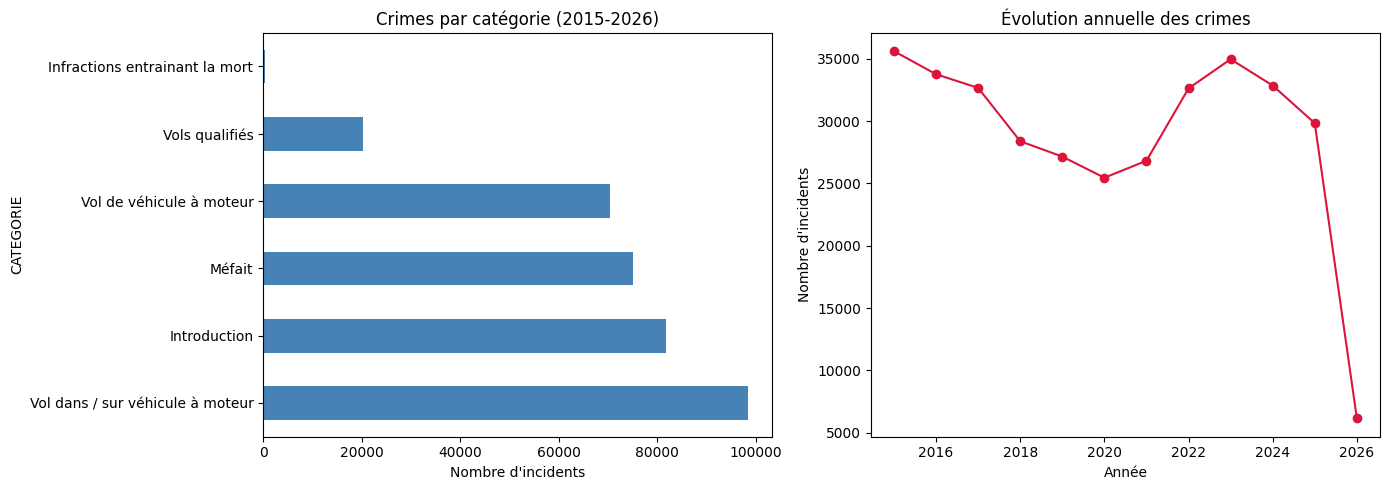

Graphique sauvegardé !


In [6]:

# Convertir DATE en format datetime
gdf['DATE'] = pd.to_datetime(gdf['DATE'])
gdf['ANNEE'] = gdf['DATE'].dt.year
gdf['MOIS'] = gdf['DATE'].dt.month

# --- Graphique 1 : Crimes par catégorie ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gdf['CATEGORIE'].value_counts().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Crimes par catégorie (2015-2026)')
axes[0].set_xlabel('Nombre d\'incidents')

# --- Graphique 2 : Évolution annuelle ---
gdf.groupby('ANNEE').size().plot(
    kind='line', ax=axes[1], marker='o', color='crimson'
)
axes[1].set_title('Évolution annuelle des crimes')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Nombre d\'incidents')

plt.tight_layout()
plt.savefig('crimes_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Graphique sauvegardé !")

💡 **Insight — Répartition par catégorie** : Les atteintes aux biens (vols dans/sur véhicule, cambriolages, vols de véhicule) représentent la grande majorité des crimes recensés à Montréal sur 11 ans. Les atteintes aux personnes restent marginales en proportion.

💡 **Insight — Évolution annuelle** : On observe une baisse continue de 2015 à 2020, suivie d'une remontée progressive jusqu'en 2023, puis une nouvelle tendance à la baisse. L'année 2026 n'étant couverte qu'au 4e mois, elle est exclue de toute interprétation de tendance.

#### 2. Aggregation plus fine sur la temporalité. 

afficher la répartition des fait enregisté sur les mois, dans l'hypothése d'une saisonnalité. 

Text(0.5, 0, "Nombre d'incidents")

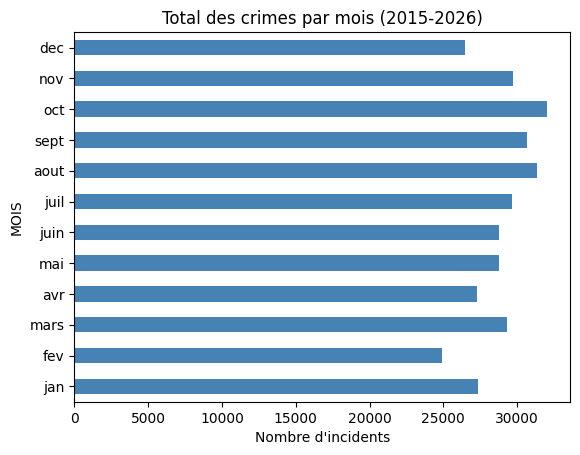

In [7]:
# quel mois est le plus criminel
fig, axes = plt.subplots()
gdf['MOIS'].value_counts().sort_index(ascending= True).plot( kind='barh', ax=axes, color='steelblue'
)
axes.set_yticklabels( labels=['jan', 'fev', 'mars','avr','mai','juin','juil','aout', 'sept','oct','nov','dec'])

axes.set_title('Total des crimes par mois (2015-2026)')
axes.set_xlabel('Nombre d\'incidents')


💡 **Insight — Saisonnalité mensuelle** : Février est le mois le plus calme et octobre le plus criminel. Une tendance saisonnière se dessine clairement : la criminalité augmente au printemps, atteint son pic en été et en automne, puis chute en hiver. Cette corrélation entre température et criminalité mériterait une analyse approfondie 

les données météorologiques de Montréal pourraient être croisées avec ce dataset pour valider ou infirmer cette hypothèse.

#### 3. Affichage par Quart
Analyser le QUART (jour/soir/nuit). au grain le plus fin dont nous disposons, existe il un moment sur la journée qui ressort.

Text(0.5, 0, "Nombre d'incidents")

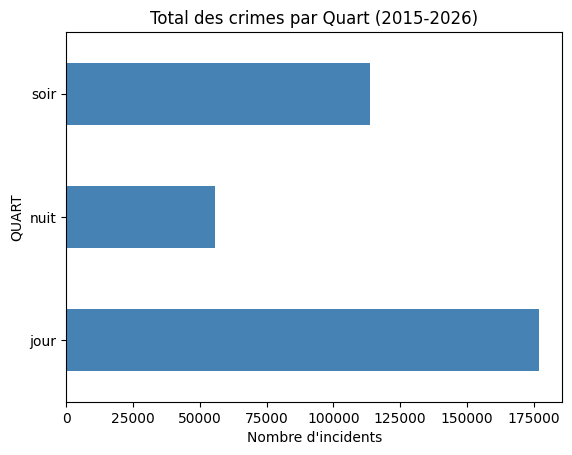

In [8]:
# quel quart est le plus criminel
fig, axes = plt.subplots()
gdf['QUART'].value_counts().sort_index(ascending= True).plot( kind='barh', ax=axes, color='steelblue'
)
axes.set_title('Total des crimes par Quart (2015-2026)')
axes.set_xlabel('Nombre d\'incidents')


💡 **Insight — Répartition par quart** : La majorité des faits sont recensés en journée. Une première interprétation est que les habitations sont inoccupées durant les heures de travail, ce qui facilite les cambriolages et les vols. 

Ce résultat renforce l'hypothèse saisonnière soulevée précédemment : en hiver, les nuits plus froides réduisent la présence dans l'espace public, les véhicules sont davantage garés à proximité des domiciles ou en garage, et les habitants restent chez eux, autant de facteurs qui pourraient expliquer la baisse hivernale de la criminalité.

Ces deux analyses combinées suggèrent que la présence humaine dans l'espace public est un facteur clé de la criminalité à Montréal 

Une hypothèse qui mériterait d'être croisée avec des données de mobilité urbaine.

#### 4. Évolution Anuelle par Catégorie

Trace l'évolution annuelle des crimes avec une ligne, mais cette fois une ligne par catégorie de crime.


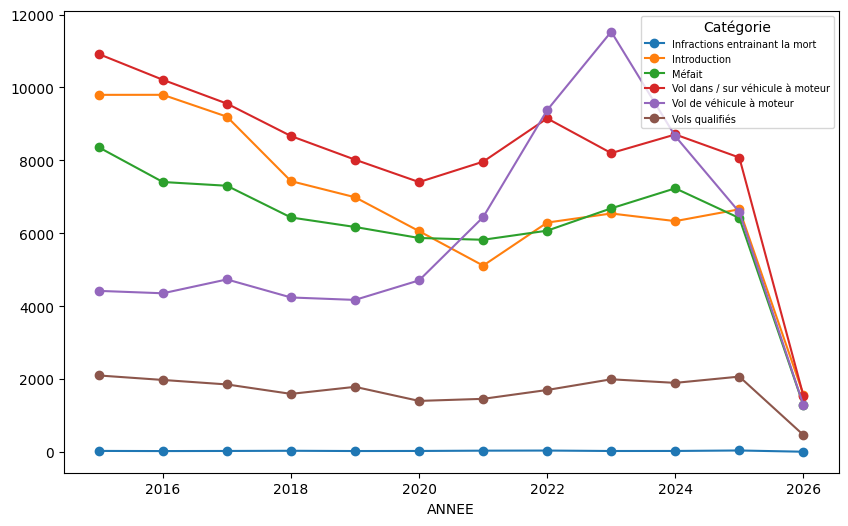

In [31]:
axes = gdf.groupby(['ANNEE', 'CATEGORIE']).size().unstack().plot(kind='line', marker='o', figsize=(10,6))
axes.legend(title='Catégorie', fontsize=7)

💡 **Insight — Évolution par catégorie** : Les faits liés aux véhicules dominent l'ensemble de la période. Le vol de véhicule a connu une croissance particulièrement marquée entre 2020 et 2023, avant de redescendre — une tendance nationale documentée, liée aux failles de sécurité des véhicules récents exploitées par le crime organisé.

Les introductions (cambriolages) affichent quant à elles une baisse globale sur 11 ans. La légère baisse de 2021 pourrait s'expliquer par le contexte du confinement, davantage de résidences occupées. La tendance baissière sur le long terme soutient l'hypothèse d'un effet dissuasif des systèmes de surveillance et de la démocratisation des dispositifs de sécurité résidentielle.

Les infractions entraînant la mort restent marginales en volume sur toute la période, ce qui est cohérent avec le profil d'une métropole nord-américaine de cette taille.

### III. Cartographie

#### 5. Gestions des valeurs nulls dans les coordonnées GPS.

Filtre sur le dataframe pour garder seulement les lignes qui ont des coordonnées GPS valides (sans NaN), et stocker le résultat dans une nouvelle variable gdf_geo.

In [10]:
# Créer la variable gdf_geo pour eliminer les lignes avec des coordonnées manquantes
gdf_geo = gdf.dropna(subset=['LONGITUDE', 'LATITUDE', 'X','Y'])
gdf_geo

,CATEGORIE,DATE,QUART,PDQ,X,Y,LONGITUDE,LATITUDE,geometry,ANNEE,MOIS
0,Vol de véhicule à moteur,2018-09-13,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780,POINT (-73.62678 45.56778),2018,9
1,Vol de véhicule à moteur,2018-04-30,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780,POINT (-73.62678 45.56778),2018,4
2,Vol de véhicule à moteur,2018-09-01,nuit,7.0,290274.565000,5.042150e+06,-73.685928,45.519122,POINT (-73.68593 45.51912),2018,9
6,Méfait,2017-07-30,jour,38.0,297654.715002,5.041877e+06,-73.591457,45.516776,POINT (-73.59146 45.51678),2017,7
8,Vol dans / sur véhicule à moteur,2017-08-01,jour,39.0,294259.780993,5.051450e+06,-73.635117,45.602873,POINT (-73.63512 45.60287),2017,8
...,...,...,...,...,...,...,...,...,...,...,...
346291,Méfait,2026-01-06,jour,23.0,302084.994993,5.046276e+06,-73.534776,45.556387,POINT (-73.53478 45.55639),2026,1
346292,Méfait,2026-03-04,jour,23.0,301550.904990,5.045183e+06,-73.541609,45.546553,POINT (-73.54161 45.54655),2026,3
346293,Méfait,2026-02-21,jour,23.0,301692.316991,5.045442e+06,-73.539800,45.548882,POINT (-73.5398 45.54888),2026,2
346294,Introduction,2026-03-08,jour,38.0,300046.665005,5.043687e+06,-73.560859,45.533085,POINT (-73.56086 45.53308),2026,3


In [41]:
# obtenir le nombre de lignes avec des coordonnées manquantes et le pourcentage de lignes avec des coordonnées manquantes
nul_par_col = gdf.isnull().sum()
percent_null= gdf.isnull().mean()*100
print("=== Pourcentage de valeurs manquantes ===")
print(percent_null)

print("=== Nombre de valeurs manquantes ===")
print(nul_par_col)


=== Pourcentage de valeurs manquantes ===
CATEGORIE     0.000000
DATE          0.000000
QUART         0.000000
PDQ           0.001733
X            16.767448
Y            16.767448
LONGITUDE    16.767448
LATITUDE     16.767448
geometry      0.000000
ANNEE         0.000000
MOIS          0.000000
dtype: float64
=== Nombre de valeurs manquantes ===
CATEGORIE        0
DATE             0
QUART            0
PDQ              6
X            58065
Y            58065
LONGITUDE    58065
LATITUDE     58065
geometry         0
ANNEE            0
MOIS             0
dtype: int64


💡 **Insight — Qualité des données** : 16,8 % des enregistrements (58 065 lignes) ne disposent pas de coordonnées GPS valides. Ce volume n'est pas négligeable, mais ces lignes restent exploitables pour les analyses statistiques (temporalité, catégories, quarts). 

Elles sont uniquement exclues des visualisations cartographiques afin d'éviter tout biais géospatial. Le dataset conservé pour la cartographie représente donc 288 231 incidents, soit 83,2 % des données initiales.

#### 6. Création d'une carte de Montreal pour une heatmap

Grâce à Folium et au point Gps disponibles ( entre 45.53, -73.60), om créer une carte  de la la ville de Montreal.

In [ ]:
#créer la variable m pour afficher la carte de montréal
m = folium.Map(
    location=[45.53, -73.60],
    zoom_start=12,
    tiles='CartoDB positron'
)
m.save("carte_montreal.html")# sauver la carte de montréal 

#### 7. Heatmap
Maintenant ajout d'une heatmap des crimes.  Pour avoir une représentation visuelle géographique sur la ville de Montreal

In [ ]:
# Construis la liste de coordonnées sous la variable heat_data
heat_data = gdf_geo[['LATITUDE','LONGITUDE']].values.tolist()

HeatMap(heat_data).add_to(m)
m.save("carte_montreal.html")#sauvegarde de la carte avec la heatmap

#### 8. Focalisation sur les voitures qui sont la plus grande recrudescences de ces onze dernière années. 

quels quartiers semblent les plus toucher ? Grâce à la heatmap précédemment créons une heatmap pour représenter ces données.

In [42]:
# Créer la variable gdf_geo_cat pour avoir que les vols
gdf_geo_cat = gdf_geo[gdf_geo['CATEGORIE'] == 'Vol dans / sur véhicule à moteur']
gdf_geo_cat.head()

,CATEGORIE,DATE,QUART,PDQ,X,Y,LONGITUDE,LATITUDE,geometry,ANNEE,MOIS
8,Vol dans / sur véhicule à moteur,2017-08-01,jour,39.0,294259.780993,5.051450e+06,-73.635117,45.602873,POINT (-73.63512 45.60287),2017,8
33,Vol dans / sur véhicule à moteur,2018-09-05,jour,38.0,297929.906992,5.042566e+06,-73.587945,45.522974,POINT (-73.58794 45.52297),2018,9
34,Vol dans / sur véhicule à moteur,2017-08-25,jour,22.0,300675.216008,5.042710e+06,-73.552803,45.524296,POINT (-73.5528 45.5243),2017,8
39,Vol dans / sur véhicule à moteur,2018-10-28,jour,21.0,300632.000007,5.041020e+06,-73.553342,45.509088,POINT (-73.55334 45.50909),2018,10
42,Vol dans / sur véhicule à moteur,2017-09-11,soir,7.0,290109.100000,5.042400e+06,-73.688054,45.521362,POINT (-73.68805 45.52136),2017,9


Une fois créer la variable gdf_geo_cat permet d'afficher sur la carte cette représentation.

In [39]:
# Construis la liste de coordonnées
heat_data_cat = gdf_geo_cat[['LATITUDE','LONGITUDE']].values.tolist()

HeatMap(heat_data_cat).add_to(m)
m.save("carte_montreal_cat.html")

#### 9. Heatmap + FeatureGroup  

En utilisant la fonction FeatureGroup et LayerControl, créons une possibiliter de filtrer sur les différentes catégories.

In [40]:
# ajouter des éléments au fg
for categorie in gdf_geo['CATEGORIE'].unique():
    #creer le featuregroup
    fg_layer = folium.FeatureGroup(name= categorie)
    gdf_geo_cat = gdf_geo[gdf_geo['CATEGORIE'] == categorie]
    heat_data_cat = gdf_geo_cat[['LATITUDE','LONGITUDE']].values.tolist()
    HeatMap(heat_data_cat).add_to(fg_layer)
    # ajouter le featuregroup a la carte
    fg_layer.add_to(m)

folium.LayerControl().add_to(m)

#sauver le tout dans la carte
m.save("carte_feature.html")

### Insight globale final sur cette analyse 

Sur la période de 11 ans, la tendance générale des faits enregistrés est à la baisse. Seule exception notable : le vol de véhicules, dont la progression a été significative avant de refluer après 2023.

Mon interprétation de cette baisse généralisée est que la démocratisation des moyens de surveillance et de protection (caméras, détecteurs, alarmes connectées) a rendu les cibles traditionnelles plus risquées pour les auteurs de faits. Les délits se déplacent naturellement vers des biens moins surveillés. À terme, le développement de l'IA et des caméras embarquées dans les véhicules pourrait également contribuer à faire reculer les vols automobiles. Sur le plan géographique, le centre-ville reste la zone la plus touchée. Sur le plan temporel, la criminalité suit une saisonnalité marquée, avec un pic en été et en automne.

**Préconisations**

Sur un plan privé :
- Rester vigilant en toute saison, avec une attention renforcée de juin à octobre.
- Investir dans des dispositifs de surveillance : caméras, détecteurs de mouvement, alarmes.
- Pour les véhicules sans accès à un garage ou parking surveillé, s'équiper de dashcams ou de systèmes d'enregistrement à détection de mouvement.

Sur un plan public :
- Renforcer la vidéosurveillance dans les zones sensibles (centre-ville, axes commerciaux).
- Augmenter les patrouilles en journée, quart où les faits sont les plus nombreux.
- Intensifier les effectifs sur la période juin–octobre.
- Développer des campagnes de prévention et de sensibilisation auprès des particuliers.

**Conclusion**

Au vu des données mises à disposition par la Ville de Montréal, la criminalité n'est objectivement pas en augmentation, contrairement à ce que laissent entendre les perceptions ambiantes. Comment expliquer alors ce sentiment croissant d'insécurité ?

**Une piste** : la multiplication des canaux d'information et des réseaux sociaux amplifie la visibilité des faits divers, créant un effet de surexposition qui déforme la perception du risque réel. Un incident isolé peut aujourd'hui être vu par des millions de personnes en quelques heures, là où il serait passé inaperçu il y a vingt ans.

Cela soulève une question de fond : les médias et réseaux sociaux ne contribuent-ils pas à entretenir un sentiment d'insécurité déconnecté de la réalité statistique ? La donnée, elle, ne ment pas mais encore faut-il savoir la lire.